<a href="https://colab.research.google.com/github/huiying8888/data-analytics/blob/main/DowJonesAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23ebf3fb&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=DJIA&scale=left&cosd=2021-03-23&coed=2026-03-23&line_color=%230073e6&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Daily%2C%20Close&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2026-03-24&revision_date=2026-03-24&nd=2016-03-24"
import pandas as pd

df = pd. read_csv(URL)
number_of_null = df.isnull().sum().sum()
print("There are " + str(number_of_null) + " null values")


There are 49 null values


In [4]:
num_rows = len(df)
null_ratio = number_of_null/num_rows
null_ratio
# we can use fstrings in python to format our strings
print(f"The null ratio is {null_ratio * 100: .4f} %")

The null ratio is  3.7548 %


In [5]:
df.dtypes
df.describe()

,DJIA
count,1256.000000
mean,37890.685669
std,5185.324605
min,28725.510000
25%,33884.095000
50%,35614.295000
75%,42200.047500
max,50188.140000


#we can create a graph to visualize the data


[Text(0.5, 1.0, 'DJIA over time')]

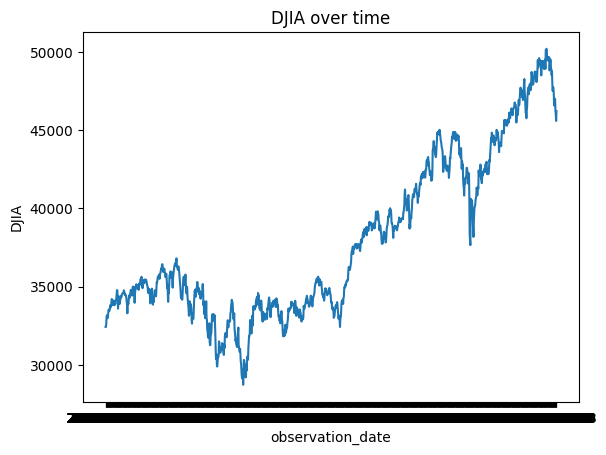

In [6]:
import seaborn as sns
ax= sns. lineplot(df, x="observation_date", y="DJIA")
ax.set(
    title="DJIA over time"
)

[Text(0.5, 1.0, 'DJIA over time')]

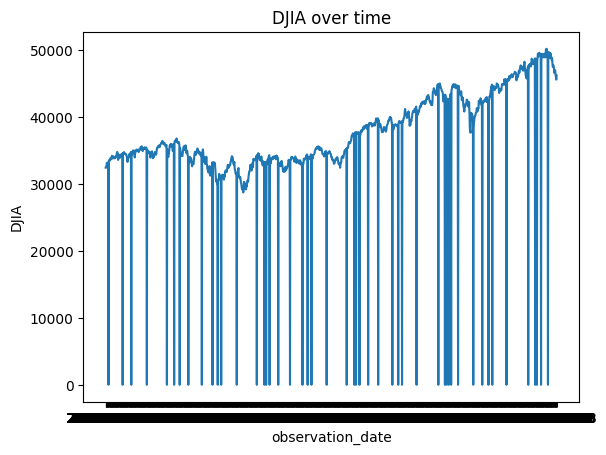

In [7]:
df2 = df.fillna(0)

ax= sns. lineplot(df2, x="observation_date", y="DJIA")
ax.set(
    title="DJIA over time"
)


Cleaning the data

In [44]:
print(len(df))
print(len(df.dropna(axis=0)))
df.dropna(axis=0,  inplace = True)

1256
1256


In [37]:
df["S&P"] = df["DJIA"] / 10

df.drop(["S&P"],axis= 1, inplace= True)

In [45]:
df

,observation_date,DJIA
0,2021-03-23,32423.15
1,2021-03-24,32420.06
2,2021-03-25,32619.48
3,2021-03-26,33072.88
4,2021-03-29,33171.37
...,...,...
1300,2026-03-17,46993.26
1301,2026-03-18,46225.15
1302,2026-03-19,46021.43
1303,2026-03-20,45577.47


In [48]:
df.iloc[1255]
df.loc[1304]


,1304
observation_date,2026-03-23
DJIA,46208.47


In [51]:
#cast
list(df.index)

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 178,
 179,
 180,
 181,
 182,
 183,
 184,
 185,
 186,
 187,
 188,
 1

In [53]:
df["DJIA"].is_unique

False

In [76]:
df.loc["2021-03-24"]

,2021-03-24
DJIA,32420.06


In [81]:
df.index = pd.to_datetime(df.index)

<Axes: xlabel='observation_date', ylabel='DJIA'>

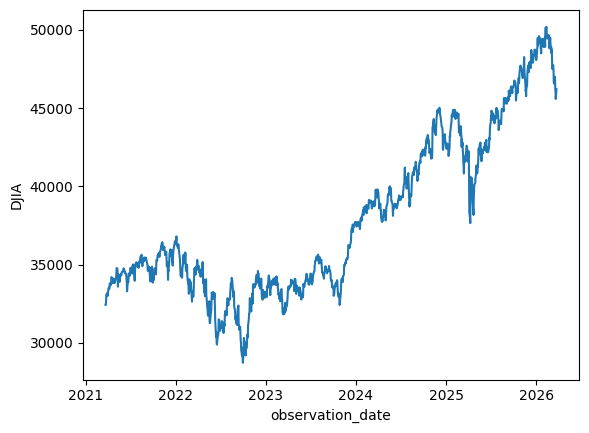

In [82]:
sns.lineplot(df, x=df.index, y="DJIA")

In [91]:
# for specific month
df.loc["2024-01"]
df.loc['2026'] #year
df[df.index.day_of_week == 4]


,DJIA
observation_date,
2021-03-26,33072.88
2021-04-09,33800.60
2021-04-16,34200.67
2021-04-23,34043.49
2021-04-30,33874.85
...,...
2026-02-20,49625.97
2026-02-27,48977.92
2026-03-06,47501.55


<Axes: xlabel='observation_date', ylabel='DJIA'>

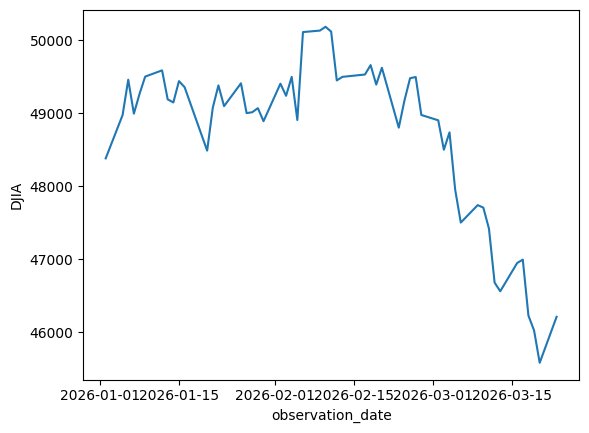

In [88]:
# Filter our data for given year

sns.lineplot(df.loc["2026"], x=df.loc["2026"].index, y="DJIA")